# Complex net experiment

Third training run: transfer learning and fine-tuning on top of a
pretrained EfficientNet-B0 backbone, instead of training a CNN from
scratch. Unlike the medium net's explicit stem + 4 stage layout,
EfficientNet-B0's `features` block is a sequential stack of 9 MBConv
stages, so this experiment doesn't preserve the same architectural shape,
only the same general idea of GAP + dropout + linear classifier on top. Same data pipeline
and shared utilities as the previous experiments.

## Downloading and extracting the dataset

Colab's local disk under /content is temporary, it gets wiped every time
the session restarts or disconnects, so this download and extraction
needs to run again at the start of every new session before anything
else.

In [ ]:
import os
os.environ['KAGGLE_API_TOKEN'] = 'your_token'

!pip install -q kaggle
!kaggle competitions download -c ifood-2019-fgvc6 -p /content/ifood_raw

100% 2.84G/2.84G [00:33<00:00, 92.0MB/s]



In [ ]:
import zipfile

extract_path = "/content/ifood/"
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile("/content/ifood_raw/ifood-2019-fgvc6.zip", "r") as zf:
    zf.extractall(extract_path)

!ls -la {extract_path}

total 2993532
drwxr-xr-x 2 root root       4096 Aug  9 12:34 .
drwxr-xr-x 1 root root       4096 Aug  9 12:33 ..
-rw-r--r-- 1 root root       3717 Aug  9 12:33 class_list.txt
-rw-r--r-- 1 root root     567555 Aug  9 12:33 ifood2019_sample_submission.csv
-rw-r--r-- 1 root root     567555 Aug  9 12:33 sample_submission.csv
-rw-r--r-- 1 root root  551912960 Aug  9 12:33 test_set.zip
-rw-r--r-- 1 root root    2435315 Aug  9 12:33 train_labels.csv
-rw-r--r-- 1 root root 2277605678 Aug  9 12:34 train_set.zip
-rw-r--r-- 1 root root     222409 Aug  9 12:34 val_labels.csv
-rw-r--r-- 1 root root  232027129 Aug  9 12:34 val_set.zip


In [ ]:
for zip_name in ["train_set.zip", "val_set.zip"]:
    print("Extracting", zip_name)
    with zipfile.ZipFile(f"/content/ifood/{zip_name}", "r") as zf:
        zf.extractall("/content/ifood/")

!ls -la /content/ifood/

Extracting train_set.zip
Extracting val_set.zip
total 2997956
drwxr-xr-x 4 root root       4096 Aug  9 12:34 .
drwxr-xr-x 1 root root       4096 Aug  9 12:33 ..
-rw-r--r-- 1 root root       3717 Aug  9 12:33 class_list.txt
-rw-r--r-- 1 root root     567555 Aug  9 12:33 ifood2019_sample_submission.csv
-rw-r--r-- 1 root root     567555 Aug  9 12:33 sample_submission.csv
-rw-r--r-- 1 root root  551912960 Aug  9 12:33 test_set.zip
-rw-r--r-- 1 root root    2435315 Aug  9 12:33 train_labels.csv
drwxr-xr-x 2 root root    4091904 Aug  9 12:34 train_set
-rw-r--r-- 1 root root 2277605678 Aug  9 12:34 train_set.zip
-rw-r--r-- 1 root root     222409 Aug  9 12:34 val_labels.csv
drwxr-xr-x 2 root root     434176 Aug  9 12:34 val_set
-rw-r--r-- 1 root root  232027129 Aug  9 12:34 val_set.zip


## Loading the shared utilities

food_utils.ipynb is kept on Drive since it holds code we want to reuse
across experiments, unlike the dataset itself which stays local for
speed. Nothing in food_utils needs to change for this experiment: the
optimizer/scheduler wiring in FoodClassifier already only optimizes
parameters with requires_grad=True, so freezing part of the backbone
here is enough to exclude it from training without touching food_utils
at all.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

# path Angy
#PROJECT_DIR = "/content/drive/MyDrive/food-project"
# path K
PROJECT_DIR = "/content/drive/MyDrive/Colab Notebooks/food-project"

UTILS_PATH = os.path.join(PROJECT_DIR, "food_utils.ipynb")

%run "{UTILS_PATH}"

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 61.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 63.5 MB/s eta 0:00:00


## Experiment configuration

Same data settings as the previous two runs. Two things change on
purpose: `lr` is much lower than the from-scratch experiments, since
fine-tuning pretrained weights with a large learning rate risks
destroying what the backbone already learned on ImageNet. `warmup_epochs`
is shorter than the medium net's, since the backbone starts from a good
initialization already and needs less ramp-up. New key: `freeze_until`,
which controls how much of the backbone stays frozen (see the
architecture cell below).

In [ ]:
CFG = {
    "data_dir": "/content/ifood",
    "img_size": 224,
    "batch_size": 64,
    "max_epochs": 150,
    "lr": 1e-4,
    "weight_decay": 1e-4,
    "dropout": 0.3,
    "val_frac": 0.15,
    "cap": 500,
    "num_workers": 2,
    "num_classes": 251,
    "warmup_epochs": 3,
    "freeze_until": "stage3",
    "unfreeze_last_n_blocks":None,
}

for key, value in CFG.items():
    print(key, ":", value)

data_dir : /content/ifood
img_size : 224
batch_size : 64
max_epochs : 150
lr : 0.0001
weight_decay : 0.0001
dropout : 0.3
val_frac : 0.15
cap : 500
num_workers : 2
num_classes : 251
warmup_epochs : 3
freeze_until : stage3
unfreeze_last_n_blocks : None


## Setting up the data module

This reads train_labels.csv, applies the class cap if set, and splits
into train and validation. The official Kaggle validation set is loaded
separately as the held-out test set. Same FoodDataModule as the previous
two experiments: the pretrained backbone still
expects 224x224 RGB input normalized with ImageNet mean/std, which is
exactly what get_transforms already does in food_utils. That
normalization choice mattered less for the from-scratch nets, but here
it actually matters: this is the same normalization the backbone was
originally trained with, so keeping it is required.

In [ ]:
dm = FoodDataModule(
    data_dir=CFG["data_dir"],
    img_size=CFG["img_size"],
    batch_size=CFG["batch_size"],
    val_frac=CFG["val_frac"],
    cap=CFG["cap"],
    num_workers=CFG["num_workers"],
)
dm.setup()

train images: 96326
val images: 16999
test images: 11994


## Preprocessing checks

Before building the model, checking that a batch has the expected shape
and that the augmentations look reasonable avoids debugging a model
against broken data later.

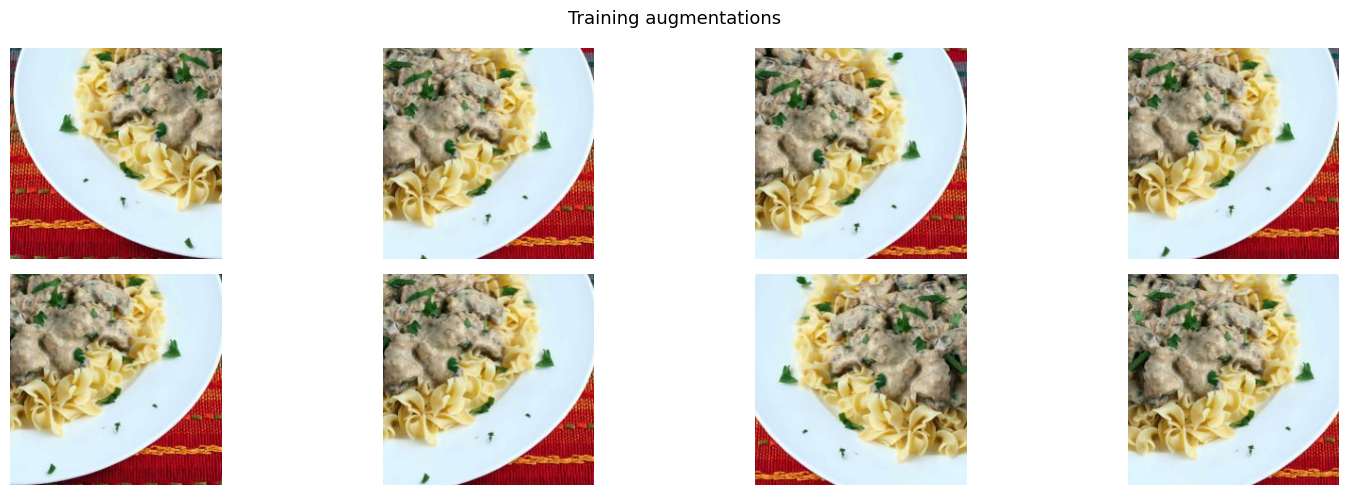

In [ ]:
sample_path = dm.train_df["path"].iloc[0]
show_augmentations(sample_path, n=8)

In [ ]:
train_loader = dm.train_dataloader()
imgs, labels = next(iter(train_loader))
print("batch shape:", imgs.shape)
print("label range:", labels.min().item(), labels.max().item())
print("pixel range:", imgs.min().item(), imgs.max().item())

batch shape: torch.Size([64, 3, 224, 224])
label range: 0 249
pixel range: -2.1179039478302 2.640000104904175


## Model architecture

The classifier head is unchanged from the previous experiments (GAP +
dropout + linear), but everything below it comes from a pretrained
EfficientNet-B0. `backbone.features` is a sequential stack of 9 blocks
(index 0 to 8): a stem conv, seven MBConv stages of increasing width,
and a final 1x1 conv. `freeze_until_block=3` freezes blocks 0 through 3
(the stem and the earlier, more generic MBConv stages) and leaves blocks
4 through 8 trainable, following the same intuition as before, low-level
features transfer well and don't need updating, higher-level ones need
to adapt to food images.

| Component          | Trainable | Notes                                   |
|---------------------|-----------|------------------------------------------|
| features[0-3]        | No        | stem + early MBConv stages, frozen        |
| features[4-8]         | Yes       | later MBConv stages + final 1x1 conv      |
| GAP                  | -         | pooled feature vector, 1280-dim           |
| Dropout              | -         | on the pooled feature vector               |
| Linear (classifier)  | Yes       | new layer, 251 classes                    |

In [ ]:
from torchvision import models


class ComplexCNN(nn.Module):
    def __init__(self, num_classes=251, dropout=0.3, freeze_until_block=4):
        super().__init__()
        backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        self.features = backbone.features
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(p=dropout)
        self.classifier = nn.Linear(backbone.classifier[1].in_features, num_classes)

        self._freeze_backbone(freeze_until_block)

    def _freeze_backbone(self, freeze_until_block):
        for i, block in enumerate(self.features):
            trainable = i > freeze_until_block
            for param in block.parameters():
                param.requires_grad = trainable

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x).flatten(1)
        x = self.dropout(x)
        return self.classifier(x)

## Building the model and checking the output shape

Before training anything, we run a dummy batch through the model to
confirm the shapes are correct end to end, and check how many parameters
are actually trainable versus frozen.

In [ ]:
model = ComplexCNN(
    num_classes=CFG["num_classes"],
    dropout=CFG["dropout"],
    freeze_until_block=4,   # regola in base a count_parameters, vedi nota sotto
)

count_parameters(model)

total_params = sum(p.numel() for p in model.parameters())
frozen_params = sum(p.numel() for p in model.parameters() if not p.requires_grad)
print("total:", f"{total_params:,}", f"({total_params/1e6:.2f}M)")
print("frozen:", f"{frozen_params:,}", f"({frozen_params/1e6:.2f}M)")

with torch.no_grad():
    dummy = torch.randn(2, 3, CFG["img_size"], CFG["img_size"])
    out = model(dummy)
    print("output shape:", out.shape)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 110MB/s] 


trainable parameters: 4,020,419 (4.02M)
total: 4,329,079 (4.33M)
frozen: 308,660 (0.31M)
output shape: torch.Size([2, 251])


## Wrapping the model for Lightning

Using AdamW with a linear warmup followed by cosine annealing, same
scheduler family as the medium net, but with a lower learning rate and
shorter warmup since we are fine-tuning a pretrained backbone rather
than training from scratch. No change needed in FoodClassifier itself:
configure_optimizers already builds its param groups from
model.named_parameters() and skips anything with requires_grad=False, so
the frozen stem/stage1/stage2 are automatically excluded from the
optimizer, not just from gradient updates.

In [ ]:
lit_model = FoodClassifier(
    model=model,
    lr=CFG["lr"],
    weight_decay=CFG["weight_decay"],
    optimizer_name="adamw",
    scheduler_type="cosine_warmup",
    warmup_epochs=CFG["warmup_epochs"],
)

## Callbacks and trainer setup

Same checkpoint / early stopping / CSV logging / learning rate monitor
setup as the medium net. Logged to its own `complex_net` directory so it
never overwrites or mixes with the base net's or medium net's checkpoints
and metrics.

In [ ]:
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping, LearningRateMonitor
from lightning.pytorch.loggers import CSVLogger

PROJECT_DIR = "/content/drive/MyDrive/food-project"
LOG_DIR = f"{PROJECT_DIR}/logs/complex_net"

checkpoint_cb = ModelCheckpoint(
    dirpath=f"{LOG_DIR}/checkpoints",
    filename="epoch={epoch:02d}-val_acc={val_acc:.4f}",
    monitor="val_acc",
    mode="max",
    save_top_k=2,
)

early_stop_cb = EarlyStopping(
    monitor="val_acc",
    patience=15,
    min_delta=0.005,
    mode="max",
)

lr_monitor = LearningRateMonitor(logging_interval="epoch")

logger = CSVLogger(save_dir=LOG_DIR, name="", version="")

trainer = L.Trainer(
    max_epochs=CFG["max_epochs"],
    callbacks=[checkpoint_cb, early_stop_cb, lr_monitor],
    logger=logger,
    accelerator="auto",
    log_every_n_steps=20,
)

print("device:", trainer.strategy.root_device)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


device: cuda:0


## Training

With a pretrained backbone and only the later blocks trainable,
convergence is typically much faster than the from-scratch experiments,
so early stopping will likely trigger well before max_epochs. Patience
is set a bit higher here (15 vs 10) to allow for slower, smaller gains
during fine-tuning compared to training from scratch.

In [ ]:
trainer.fit(lit_model, datamodule=dm)

/usr/local/lib/python3.12/dist-packages/lightning/fabric/loggers/csv_logs.py:268: Experiment logs directory /content/drive/MyDrive/food-project/logs/complex_net/ exists and is not empty. Previous log files in this directory will be deleted when the new ones are saved!


train images: 96326
val images: 16999
test images: 11994


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ ComplexCNN       │  4.3 M │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss │      0 │ train │     0 │
└───┴───────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 4.0 M                                                                                            
Non-trainable params: 308 K                                                                                        
Total params: 4.3 M                                                                                                
Total estimated model params size (MB): 17.316                                                                     
Modules in train mode: 337                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

## Loading the best checkpoint and evaluating on the test set

In [ ]:
best_ckpt = checkpoint_cb.best_model_path
print("best checkpoint:", best_ckpt)

eval_model = ComplexCNN(
    num_classes=CFG["num_classes"],
    dropout=CFG["dropout"],
    freeze_until_block=4,
)
best_lit_model = FoodClassifier.load_from_checkpoint(best_ckpt, model=eval_model)
best_lit_model.eval()

device = "cuda" if torch.cuda.is_available() else "cpu"

best checkpoint: /content/drive/MyDrive/food-project/logs/complex_net/checkpoints/epoch=epoch=18-val_acc=val_acc=0.5788.ckpt


In [ ]:
test_loader = dm.test_dataloader()
y_true, y_pred = predict_all(best_lit_model.model, test_loader, device=device)

metrics = evaluate(y_true, y_pred, verbose=True)

metrics["experiment"] = "complex_net"
metrics["config"] = CFG

import json
os.makedirs(LOG_DIR, exist_ok=True)
with open(f"{LOG_DIR}/metrics_summary.json", "w") as f:
    json.dump(metrics, f, indent=2)

accuracy : 0.6492
macro_precision : 0.6403
macro_recall : 0.6375
macro_f1 : 0.6323
weighted_f1 : 0.6469


Best numbers of the three by a clear margin, +7 points over MediumNet, +12 over BaseNet. Precision and recall are close together here (0.6403 vs 0.6375), tighter than MediumNet's gap.

ImageNet pretraining hands the model features that already generalize well to natural images before it ever sees a single food photo, so it's starting from a much better place than either from-scratch net.

## Training curves and confusion matrix

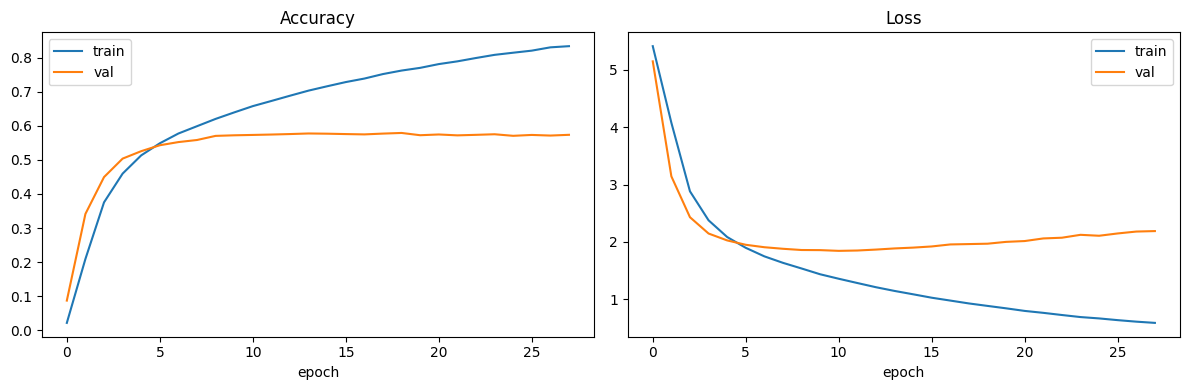

In [ ]:
plot_training_curves(LOG_DIR)

It's actually worse than MediumNet's overfitting in relative terms. Val accuracy locks in around 0.57-0.58 by epoch 8-10 and just sits there, meanwhile train keeps grinding up to 0.83+ by epoch 27. Loss shows the same thing even more clearly, val bottoms out near 1.8 around epoch 10 then drifts back up to 2.15, while train keeps falling all the way to 0.4.

So despite this being the best test accuracy of the three, it's also the most overfit run. Makes sense actually, only the later blocks plus the classifier are trainable here, and those parameters can adapt to fit the training set fast once they're sitting on top of already-good pretrained features.

Best checkpoint landed at epoch 18, which is already well past where val stopped improving (around epoch 8-10).

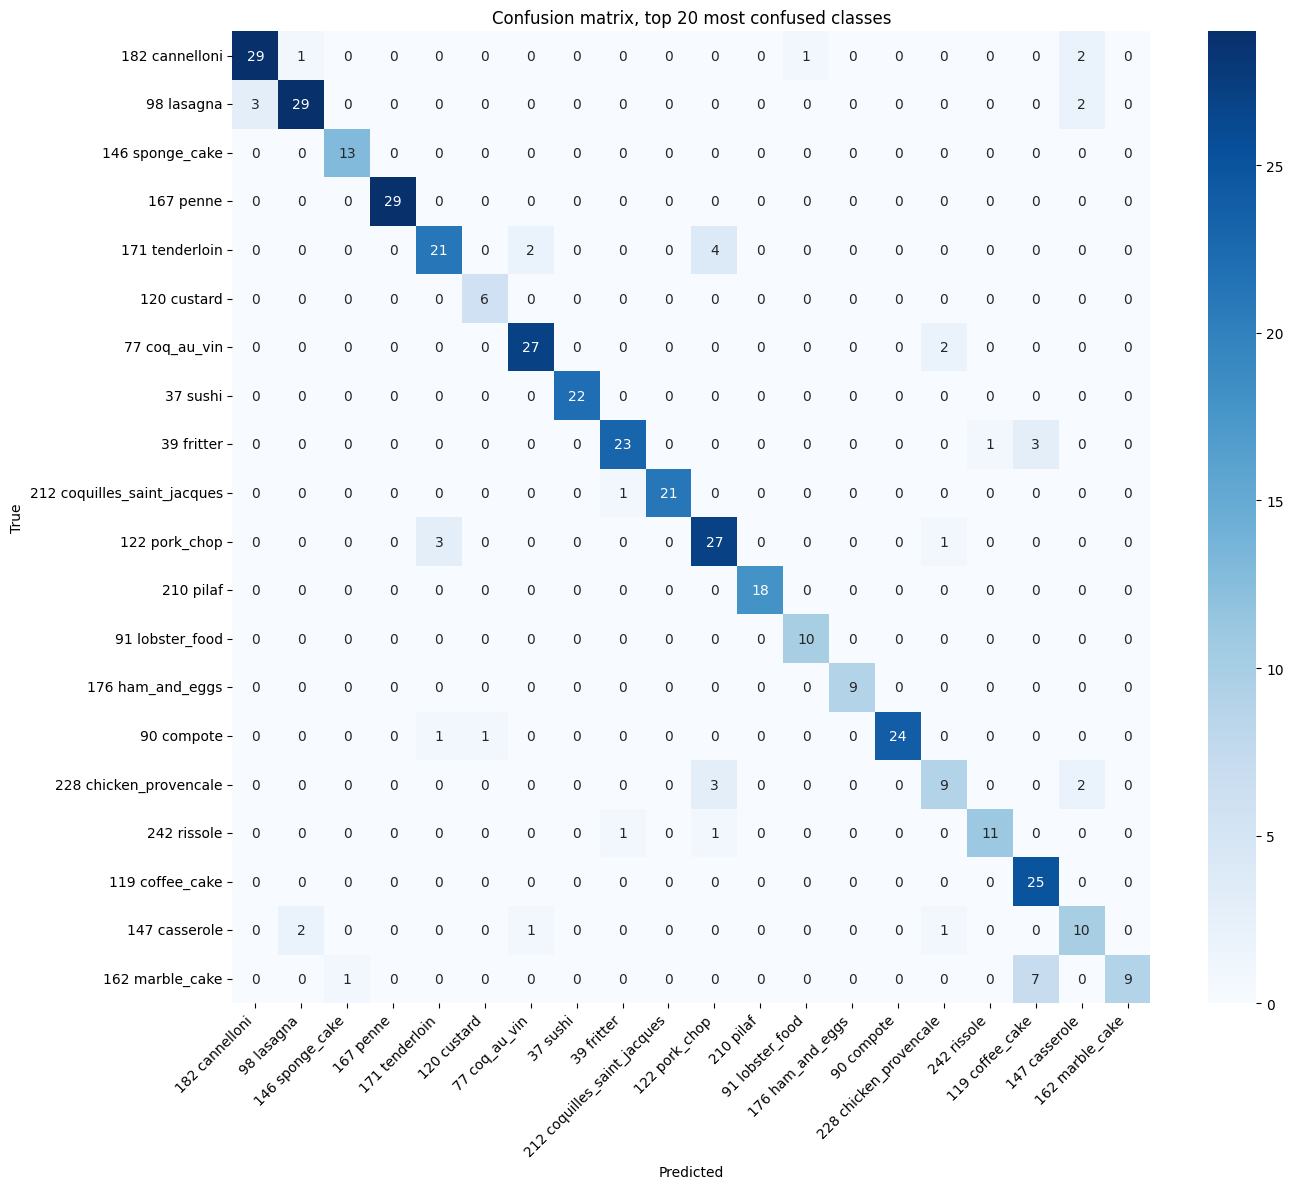

In [ ]:
class_names_path = f"{CFG['data_dir']}/class_list.txt"
class_names = None
if os.path.exists(class_names_path):
    with open(class_names_path) as f:
        class_names = [line.strip() for line in f.readlines()]

plot_confusion_matrix(y_true, y_pred, class_names=class_names, top_n=20)

This is a nicer matrix, here more classes sit clean at their diagonal peak than either BaseNet or MediumNet.

Biggest story here though is chicken provencale actually working now. That class was a disaster in both earlier models, BaseNet barely got any of it right at all. Here it's sitting at 9 correct, with a few slipping into pork chop and coffee cake, still not perfect but a real jump from near-zero recall.

Marble cake is still the weak point, with 9 right but 7 going to coffee cake and 1 to sponge cake. At this point it's pretty clear this isn't a capacity problem at all, three very different models all fail on it the same way, so it's almost certainly the training data itself, too few and maybe too visually similar to other cakes to separate.

Small mutual mix-up between cannelloni and lasagna too, 3 lasagna called cannelloni and vice versa, which tracks, they're both pasta tubes in red sauce and probably look nearly identical from most angles. Tenderloin also leaks into pork chop and custard a bit, still the most confused of the meat dishes here.

In [ ]:
# Unassign the runtime in order to not waste paid computing units
from google.colab import runtime
runtime.unassign()